# 1. Visualizing data: asking a clear question

Learn to choose a bar chart, histogram, scatter plot, or time-ordered line plot; label axes; inspect the effect of binning; and avoid confusing association with causation. Prerequisite: [Pandas basics](../../../01_Python_Foundations/16_pandas_basics.ipynb). You will use both Matplotlib and Seaborn with invented, local data. Allow two hours and explain each figure aloud before reading its interpretation.

## 2. What problem does this solve?

A table can contain a pattern that is hard to recognize row by row. A graph maps values to visual positions, lengths, colors, or areas so that comparison becomes easier. A useful graph answers a question: how much, how distributed, how related, or how changing over time? Choosing the question precedes choosing a plotting function.

Visualization is also a diagnostic tool. Impossible values, separated groups, and extreme observations may reveal data-quality problems before a model is fitted. A striking pattern is a reason to investigate, not permission to skip evaluation.

## 3. Intuition and analogy

Think of a chart as a measuring instrument. A ruler with uneven markings can make identical lengths appear different. Similarly, a truncated axis or unequal bins can distort numerical differences. The instrument should make the intended comparison easier without quietly changing what a viewer perceives.

Bars compare categories; histograms count numerical observations in intervals; scatter plots place one point per paired observation; line plots connect ordered measurements. Joining unrelated categories with lines suggests a continuity that may not exist.

## 4. Terminology

An **axis** maps a data quantity to a position. A **scale** controls the mapping, such as linear or logarithmic. A **bin** is an interval used in a histogram. **Frequency** is a count. A **distribution** describes how values occur across a range. **Association** means values tend to vary together; **causation** means changing one factor changes another under a defensible causal interpretation.

A **legend** explains visual encodings. A **caption** states the question, observation, and relevant limitation. An **outlier** is unusual relative to a context; it may be a mistake or an important real event. A **seed** fixes the initial state of a pseudorandom generator so a demonstration can be repeated.

## 5. Mathematical foundations

For bin $j$ with lower edge $a_j$ and upper edge $b_j$, its count is

$$h_j=\sum_{i=1}^{n}\mathbf{1}[a_j\le x_i<b_j].$$

$x_i$ is observation $i$, $n$ is the number of observations, and $\mathbf{1}[\cdot]$ equals one when its condition is true and zero otherwise. Thus each observation contributes one to the bin containing it. Counts have units of observations. NumPy includes the final rightmost edge in the final bin, a boundary convention we must state explicitly.

For equal-width bins, comparing heights compares counts directly. Unequal-width bins require care: a wider interval may contain more values simply because it covers more range. A density histogram instead scales area to probability; density height is not itself a probability.

## 6. Hand-calculated example

Take waiting times `[0,1,1,2,3,5]` minutes and edges `[0,2,4,6]`. The first interval, $[0,2)$, contains 0, 1, and 1: count three. The next interval contains 2 and 3: count two. The last contains 5: count one. Counts add to six, the sample size. The mean is $12/6=2$ minutes, but the histogram reveals that many waits are below the mean.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
waits = [0, 1, 1, 2, 3, 5]
edges = [0, 2, 4, 6]
manual_counts = []
for low, high in zip(edges[:-1], edges[1:]):
    count = sum(low <= value < high for value in waits)
    manual_counts.append(count)
print('Hand-style counts:', manual_counts)
assert manual_counts == [3, 2, 1]

Hand-style counts: [3, 2, 1]


No value equals the final edge in this example, so our simple half-open loop agrees with NumPy. A general implementation must also handle values on that last boundary. The small example makes the statistical mechanism visible without claiming to replace a production histogram routine.

## 8. Step-by-step output inspection

In [3]:
import numpy as np
counts, returned_edges = np.histogram(waits, bins=edges)
print('Library counts:', counts, 'Edges:', returned_edges)
np.testing.assert_array_equal(counts, manual_counts)
assert counts.sum() == len(waits)
assert np.mean(waits) == 2

Library counts: [3 2 1] Edges: [0 2 4 6]


Check that the counts sum to the number of observations inside the plotted range. Values outside explicit bin edges are excluded, so a matching total is not automatic. Reporting only the picture could conceal that exclusion.

## 9. Library implementation

Matplotlib gives direct control over axes and marks. Seaborn offers convenient statistical displays based on tidy tables, where each row is an observation and each column a variable. Some Seaborn functions aggregate by default; inspect that behavior rather than assuming each mark represents one original row.

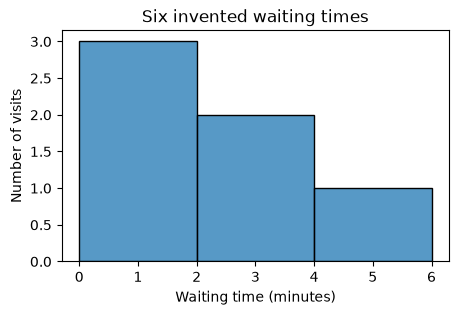

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
waiting_table = pd.DataFrame({'minutes': waits})
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=waiting_table, x='minutes', bins=edges, stat='count', ax=ax)
ax.set(xlabel='Waiting time (minutes)', ylabel='Number of visits', title='Six invented waiting times')
display(fig)
plt.close(fig)

## 10. Visualization and interpretation

The highest bar is the 0–2 minute interval, containing three visits. The plot does not imply all three waits equal one minute; binning hides exact locations. With only six observations, conclusions about a service's overall reliability would be weak. Report the sample size and collection period when using real data.

Now inspect an association using paired values. The same row must supply both coordinates; separately sorting the columns would destroy their original pairing.

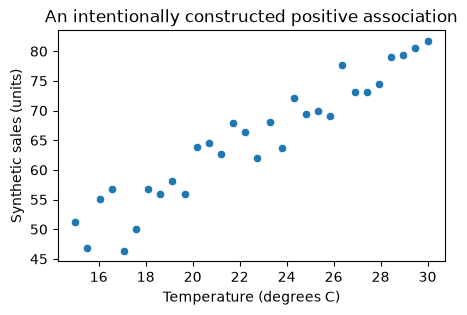

In [5]:
rng = np.random.default_rng(42)
temperature = np.linspace(15, 30, 30)
sales = 20 + 2 * temperature + rng.normal(0, 4, size=30)
synthetic = pd.DataFrame({'temperature_C': temperature, 'sales_units': sales})
fig, ax = plt.subplots(figsize=(5, 3))
sns.scatterplot(data=synthetic, x='temperature_C', y='sales_units', ax=ax)
ax.set(xlabel='Temperature (degrees C)', ylabel='Synthetic sales (units)', title='An intentionally constructed positive association')
display(fig)
plt.close(fig)
assert len(synthetic) == 30

## 11. Realistic experiment: change the display

The previous data were generated by an equation, so their association was designed. They are not evidence that temperature causes sales in the real world. A real observational dataset might mix temperature, season, holidays, and advertising.

Compare coarse and fine bins on the same simulated waiting times. The sample is deterministic because its generator is seeded, but repeated samples from a real process would differ.

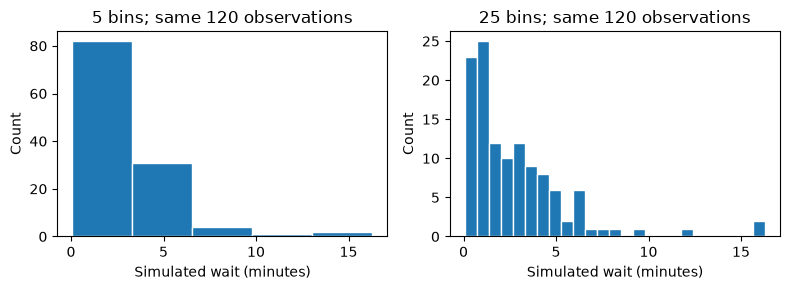

In [6]:
sample = rng.exponential(scale=3, size=120)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, number in zip(axes, [5, 25]):
    ax.hist(sample, bins=number, edgecolor='white')
    ax.set(xlabel='Simulated wait (minutes)', ylabel='Count', title=f'{number} bins; same 120 observations')
fig.tight_layout()
display(fig)
plt.close(fig)

The coarse plot emphasizes the broad right tail. The fine plot shows irregular local counts that could be mistaken for meaningful subgroups. Neither plot adds information that the original sample did not contain.

## 12. Choices and experiments

Binning, axis limits, marker opacity, scale, and grouping affect a chart's readability. These are visualization settings, not learned model parameters. Begin with defaults, then justify changes in terms of the question. Do not repeatedly search for a view that makes a preferred conclusion look convincing. Save both helpful and contradictory views during exploratory work.

## 13. Evaluation

Ask whether a reader can identify units, sample size, meaning of one mark, and the comparison being made. Check calculations independently. Are omitted values disclosed? Can color-blind readers distinguish groups through marker shape or labels? Can the figure remain interpretable when printed without color? A pretty chart that hides its denominators is a poor analytical result.

## 14. Assumptions and limitations

Every display compresses information. A mean bar hides spread; a histogram hides exact values; a scatter plot can hide overlapping points. A log scale is useful for multiplicative differences but cannot directly show zero or negative values. Time plots assume meaningful ordering. A sampled graph cannot alone establish population behavior or a causal effect.

## 15. Common mistakes and debugging

Avoid a truncated vertical baseline for bars when length encodes magnitude. Do not use a pie chart with many almost equal categories. Do not connect unordered rows with a line. Check for missing values silently dropped by plotting routines. Distinguish counts from normalized proportions: different group sizes can reverse the apparent message if denominators are ignored.

## 16. Comparison with alternatives

A table is often better when exact values matter. A box plot summarizes median and quartiles compactly but hides some distribution detail. A scatter plot can show structure that a single correlation coefficient misses. Use multiple complementary displays when a decision depends on a pattern, while explaining why each was chosen.

## 17. Exercises

1. **Beginner:** Choose a chart for comparing revenue across three products and justify the axis baseline.
2. **Beginner:** Count values `[1,2,2,4]` in bins `[0,2,4,6]` using the stated edge convention.
3. **Beginner:** Write a caption for the waiting-time histogram including sample size and limitation.
4. **Intermediate:** Explain what changes when the histogram uses proportions rather than counts.
5. **Intermediate:** Explain why independently sorting temperature and sales before plotting would mislead.
6. **Challenge:** Design a fair visualization comparing waits at two clinics with different sample sizes, including a numerical check and an uncertainty limitation.

## 18. Detailed solutions

1. Use bars with product names on the horizontal axis and revenue units vertically. Start the length-encoding axis at zero to preserve amount comparisons.
2. Counts are `[1,2,1]`: one is in the first interval, both twos in the second, and four in the third.
3. “Of six invented visits, three waited under two minutes; the small teaching sample cannot characterize a real service.” This states observation and scope.
4. Divide each bin count by the total number of observations. Heights then represent fractions for those bins; this enables comparison of samples with different sizes when bin definitions match.
5. Sorting separately creates new pairs that were never observed. It can manufacture a strong increasing association even when the original variables were unrelated.
6. Use common bin edges and proportions, report each sample size, and compare medians and tail fractions. Keep the observation window and inclusion rules comparable. A smaller clinic sample has greater sampling uncertainty; neither a single chart nor a median difference proves a causal clinic effect.

In [7]:
exercise_counts, _ = np.histogram([1, 2, 2, 4], bins=[0, 2, 4, 6])
np.testing.assert_array_equal(exercise_counts, [1, 2, 1])
proportions = exercise_counts / exercise_counts.sum()
assert np.isclose(proportions.sum(), 1)
print('Bin proportions:', proportions)

Bin proportions: [0.25 0.5  0.25]


## 19. Knowledge check

**Histogram versus bar chart?** Numerical intervals versus categories. **What does a scatter point represent?** Paired measurements from one observation. **Why a seed?** To reproduce this random demonstration. **Can correlation prove causation?** No. **Why show units?** Numerical differences have no practical scale without them.

## 20. Interview preparation

**How select a chart?** Start with the comparison and data types. **Why can bins mislead?** Different widths and counts alter apparent structure. **How handle overplotting?** Use opacity, smaller markers, density summaries, or a stated sample. **Why compare proportions across unequal groups?** Raw counts confound frequency with group size. **How prevent visualization leakage?** Keep test outcomes out of iterative modeling choices; use training and validation data for exploration that informs model design.

## 21. Summary and next steps

A chart is an argument grounded in a data transformation. Make both visible. Continue to [Scalars, vectors and matrices](../../../02_Mathematics_for_ML/07_scalars_vectors_and_matrices.ipynb) to understand the numerical objects behind these tables.